# 🎙️ Notebook 1 — Data Preprocessing & Splice Simulation
## Forensic Audio Authentication using Deep Learning

---

### 📋 Ce que fait ce notebook
1. Vérifie l'environnement GPU et installe les dépendances
2. Monte et explore les 3 datasets (LJSpeech, WaveFake, ASVspoof2019 LA)
3. Rééchantillonne tous les audios à 16kHz (standard forensique)
4. Simule 1000 clips splicés à partir de LJSpeech (notre contribution originale)
5. Construit le fichier master_labels.csv unifié avec splits 80/10/10
6. Sauvegarde tout en dataset Kaggle pour les notebooks suivants

### ⏱️ Durée estimée : 30–45 minutes GPU

### 📂 Structure des inputs attendus sur Kaggle
```
/kaggle/input/ljspeech/LJSpeech-1.1/wavs/          ← clips .wav LJSpeech
/kaggle/input/wavefake/generated_audio/             ← clips générés par vocoders
/kaggle/input/asvspoof2019/LA/ASVspoof2019_LA_train/flac/   ← train .flac
/kaggle/input/asvspoof2019/LA/ASVspoof2019_LA_dev/flac/     ← dev .flac
/kaggle/input/asvspoof2019/LA/ASVspoof2019_LA_eval/flac/    ← eval .flac
/kaggle/input/asvspoof2019/LA/ASVspoof2019_LA_cm_protocols/ ← fichiers labels
```

---
## CELLULE 1 — Vérification GPU et environnement

In [38]:
import torch
import sys

# ── Vérification GPU ──────────────────────────────────────────────────────────
print('=' * 60)
print('VÉRIFICATION ENVIRONNEMENT')
print('=' * 60)
print(f'Python version     : {sys.version.split()[0]}')
print(f'PyTorch version    : {torch.__version__}')
print(f'GPU disponible     : {torch.cuda.is_available()}')

if torch.cuda.is_available():
    print(f'Nom du GPU         : {torch.cuda.get_device_name(0)}')
    print(f'Mémoire GPU totale : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    device = torch.device('cuda')
    print('✅ GPU prêt à utiliser')
else:
    device = torch.device('cpu')
    print('⚠️  Aucun GPU détecté — aller dans Settings > Accelerator > GPU T4 x2')

print(f'Device utilisé     : {device}')
print('=' * 60)

VÉRIFICATION ENVIRONNEMENT
Python version     : 3.12.12
PyTorch version    : 2.10.0+cu128
GPU disponible     : True
Nom du GPU         : Tesla T4
Mémoire GPU totale : 15.6 GB
✅ GPU prêt à utiliser
Device utilisé     : cuda


---
## CELLULE 2 — Installation des dépendances

In [39]:
# ── Installation des librairies non-disponibles par défaut sur Kaggle ─────────
# torchaudio est déjà installé sur Kaggle — on vérifie juste
import subprocess

packages = [
    'speechbrain',   # baselines anti-spoofing
    'soundfile',     # lecture fichiers .flac (ASVspoof)
]

for pkg in packages:
    print(f'Installation de {pkg}...')
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', pkg, '-q'],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        print(f'  ✅ {pkg} installé')
    else:
        print(f'  ❌ Erreur : {result.stderr[:100]}')

print('\n✅ Toutes les dépendances sont prêtes')

Installation de speechbrain...
  ✅ speechbrain installé
Installation de soundfile...
  ✅ soundfile installé

✅ Toutes les dépendances sont prêtes


---
## CELLULE 3 — Imports et configuration globale

In [40]:
import os
import random
import shutil
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from tqdm.notebook import tqdm

import torch
import torchaudio
import torchaudio.transforms as T

warnings.filterwarnings('ignore')

# ── Reproductibilité ──────────────────────────────────────────────────────────
# Fixer les seeds garantit que les mêmes résultats sont obtenus à chaque run
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Paramètres globaux du projet ──────────────────────────────────────────────
# Ces valeurs viennent directement du cahier des charges
SAMPLE_RATE    = 16000     # 16kHz — standard forensique
CLIP_DURATION  = 4         # secondes — longueur fixe de chaque clip
CLIP_SAMPLES   = SAMPLE_RATE * CLIP_DURATION  # = 64 000 échantillons
N_LFCC         = 20        # nombre de coefficients LFCC
N_FFT          = 400       # fenêtre 25ms à 16kHz (400 échantillons)
HOP_LENGTH     = 160       # pas 10ms à 16kHz (160 échantillons)
N_FILTER       = 128       # nombre de filtres linéaires
N_SPLICES      = 1000      # clips splicés à générer
CROSSFADE_MS   = 20        # durée du crossfade en millisecondes

# ── Chemins des datasets sur Kaggle ───────────────────────────────────────────
# ⚠️  ADAPTER CES CHEMINS selon le nom exact de tes datasets uploadés
LJSPEECH_DIR   = Path('//kaggle/input/datasets/elmiz20042004/forensic-audio-dataset/LJSpeech-1.1/LJSpeech-1.1/wavs')
WAVEFAKE_DIR   = Path('/kaggle/input/datasets/elmiz20042004/forensic-audio-dataset/generated_audio/generated_audio')
ASVSPOOOF_DIR  = Path('/kaggle/input/datasets/elmiz20042004/forensic-audio-dataset/LA/LA')

# ── Chemins de sortie (dans /kaggle/working/ — sauvegardés entre sessions) ────
OUTPUT_DIR       = Path('/kaggle/working')
RESAMPLED_LJ_DIR = OUTPUT_DIR / 'ljspeech_16k'
SPLICED_DIR      = OUTPUT_DIR / 'spliced'
SPLITS_DIR       = OUTPUT_DIR / 'splits'

# Créer les dossiers de sortie
for d in [RESAMPLED_LJ_DIR, SPLICED_DIR, SPLITS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('✅ Configuration chargée')
print(f'   SAMPLE_RATE  = {SAMPLE_RATE} Hz')
print(f'   CLIP_SAMPLES = {CLIP_SAMPLES} ({CLIP_DURATION}s × {SAMPLE_RATE}Hz)')
print(f'   N_LFCC       = {N_LFCC} coefficients')
print(f'   N_FFT        = {N_FFT} ({N_FFT/SAMPLE_RATE*1000:.0f}ms fenêtre)')
print(f'   HOP_LENGTH   = {HOP_LENGTH} ({HOP_LENGTH/SAMPLE_RATE*1000:.0f}ms pas)')

✅ Configuration chargée
   SAMPLE_RATE  = 16000 Hz
   CLIP_SAMPLES = 64000 (4s × 16000Hz)
   N_LFCC       = 20 coefficients
   N_FFT        = 400 (25ms fenêtre)
   HOP_LENGTH   = 160 (10ms pas)


---
## CELLULE 4 — Fonctions utilitaires de preprocessing audio

> **Pourquoi ces fonctions ?**  
> Chaque clip qui entre dans le modèle doit avoir exactement la même forme.  
> - `normalize_length` : assure que tous les clips font 4 secondes pile  
> - `normalize_amplitude` : élimine les différences de volume entre micros/enregistreurs  
> - `load_audio` : charge n'importe quel format (.wav ou .flac) et applique toutes les normalisations

In [41]:
def normalize_length(waveform, target_samples=CLIP_SAMPLES):
    """
    Tronque ou complète un waveform pour qu'il fasse exactement target_samples.
    
    - Si trop long  → on prend la partie CENTRALE (évite le silence en début/fin)
    - Si trop court → on complète avec des zéros (silence) à droite
    
    Args:
        waveform       : Tensor de forme (1, N)
        target_samples : nombre d'échantillons voulu (défaut: 64000 = 4s à 16kHz)
    Returns:
        Tensor de forme (1, target_samples) — TOUJOURS
    """
    current = waveform.shape[1]
    
    if current >= target_samples:
        # Tronquer depuis le centre — la parole utile est souvent au milieu
        start = (current - target_samples) // 2
        waveform = waveform[:, start : start + target_samples]
    else:
        # Compléter avec des zéros (silence) à droite
        pad_amount = target_samples - current
        waveform = torch.nn.functional.pad(waveform, (0, pad_amount))
    
    assert waveform.shape[1] == target_samples, \
        f"Erreur normalize_length: {waveform.shape[1]} ≠ {target_samples}"
    return waveform


def normalize_amplitude(waveform, target_db=-20.0):
    """
    Normalise l'amplitude du waveform à un niveau RMS cible.
    
    Pourquoi ? Deux enregistrements du même locuteur peuvent avoir des volumes
    très différents selon le micro utilisé. Sans normalisation, le modèle peut
    apprendre à classer selon le volume plutôt que selon les artefacts.
    
    Args:
        waveform  : Tensor de forme (1, N)
        target_db : niveau RMS cible en dBFS (défaut: -20 dB)
    Returns:
        Tensor normalisé, clampé entre [-1.0, 1.0]
    """
    rms = waveform.pow(2).mean().sqrt()
    
    if rms > 1e-8:  # Éviter division par zéro sur les clips silencieux
        target_rms = 10 ** (target_db / 20.0)
        waveform = waveform * (target_rms / rms)
    
    # Clamp pour éviter la saturation numérique
    waveform = waveform.clamp(-1.0, 1.0)
    return waveform


def load_audio(filepath, target_sr=SAMPLE_RATE):
    """
    Charge un fichier audio (.wav ou .flac), applique toutes les normalisations.
    
    Étapes appliquées :
    1. Chargement (torchaudio supporte .wav et .flac)
    2. Rééchantillonnage à 16kHz si nécessaire
    3. Conversion Stéréo → Mono (moyenne des canaux)
    4. Normalisation de longueur à 4 secondes
    5. Normalisation d'amplitude à -20 dBFS
    
    Args:
        filepath  : chemin vers le fichier audio
        target_sr : sample rate cible (défaut: 16000 Hz)
    Returns:
        Tensor de forme (1, 64000) — toujours
    """
    waveform, sr = torchaudio.load(str(filepath))
    
    # Étape 1 : Rééchantillonnage
    if sr != target_sr:
        resampler = T.Resample(orig_freq=sr, new_freq=target_sr)
        waveform = resampler(waveform)
    
    # Étape 2 : Stéréo → Mono
    # Explication : les datasets forensiques sont en mono
    # Les artefacts de manipulation sont identiques dans les 2 canaux
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    
    # Étape 3 : Longueur fixe
    waveform = normalize_length(waveform)
    
    # Étape 4 : Amplitude normalisée
    waveform = normalize_amplitude(waveform)
    
    return waveform  # forme: (1, 64000)


print('✅ Fonctions utilitaires définies')
print('   - normalize_length()   : pad/truncate à 4 secondes')
print('   - normalize_amplitude(): normalisation RMS à -20dBFS')
print('   - load_audio()         : pipeline complet de chargement')

✅ Fonctions utilitaires définies
   - normalize_length()   : pad/truncate à 4 secondes
   - normalize_amplitude(): normalisation RMS à -20dBFS
   - load_audio()         : pipeline complet de chargement


---
## CELLULE 5 — Test des fonctions utilitaires

> **Règle d'or** : toujours tester sur 1 fichier avant de lancer sur 13 000.

In [42]:
import os

# Voir ce qui est réellement monté
for root, dirs, files in os.walk('/kaggle/input'):
    level = root.replace('/kaggle/input', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:  # Limiter la profondeur
        for f in files[:5]:  # 5 fichiers max par dossier
            print(f'{indent}  {f}')

input/
  datasets/
    elmiz20042004/
      forensic-audio-dataset/
        generated_audio/
          generated_audio/
            jsut_parallel_wavegan/
            ljspeech_melgan_large/
            ljspeech_waveglow/
            ljspeech_parallel_wavegan/
            ljspeech_full_band_melgan/
            ljspeech_melgan/
            ljspeech_multi_band_melgan/
            jsut_multi_band_melgan/
        LJSpeech-1.1/
          LJSpeech-1.1/
            wavs/
        LA/
          LA/
            ASVspoof2019_LA_dev/
              flac/
            ASVspoof2019_LA_train/
              flac/
            ASVspoof2019_LA_cm_protocols/
            ASVspoof2019_LA_eval/
              flac/
            ASVspoof2019_LA_asv_protocols/
            ASVspoof2019_LA_asv_scores/


In [43]:
# ── Test sur un fichier LJSpeech ──────────────────────────────────────────────
lj_files = sorted(LJSPEECH_DIR.glob('*.wav'))
print(f'📁 LJSpeech : {len(lj_files):,} fichiers .wav trouvés')

if len(lj_files) == 0:
    print('❌ Aucun fichier trouvé — vérifier le chemin LJSPEECH_DIR')
    print(f'   Chemin cherché : {LJSPEECH_DIR}')
else:
    # Test sur le premier fichier
    test_file = lj_files[0]
    
    # Charger sans normalisation pour voir l'original
    raw_waveform, raw_sr = torchaudio.load(str(test_file))
    print(f'\n📊 Fichier test : {test_file.name}')
    print(f'   Sample rate original : {raw_sr} Hz')
    print(f'   Forme originale      : {raw_waveform.shape}')
    print(f'   Durée originale      : {raw_waveform.shape[1]/raw_sr:.2f} secondes')
    
    # Appliquer le pipeline complet
    processed = load_audio(test_file)
    print(f'\n   Après load_audio():')
    print(f'   Forme traitée        : {processed.shape}')
    print(f'   Durée traitée        : {processed.shape[1]/SAMPLE_RATE:.2f} secondes')
    print(f'   Min/Max amplitude    : {processed.min():.4f} / {processed.max():.4f}')
    
    # Vérification critique
    assert processed.shape == (1, CLIP_SAMPLES), \
        f'❌ Shape incorrecte: {processed.shape} au lieu de (1, {CLIP_SAMPLES})'
    print(f'\n   ✅ Shape correcte : {processed.shape}')

📁 LJSpeech : 13,100 fichiers .wav trouvés

📊 Fichier test : LJ001-0001.wav
   Sample rate original : 22050 Hz
   Forme originale      : torch.Size([1, 212893])
   Durée originale      : 9.66 secondes

   Après load_audio():
   Forme traitée        : torch.Size([1, 64000])
   Durée traitée        : 4.00 secondes
   Min/Max amplitude    : -0.6383 / 0.8077

   ✅ Shape correcte : torch.Size([1, 64000])


---
## CELLULE 6 — Exploration visuelle des datasets

> Avant de traiter quoi que ce soit, on visualise les données pour comprendre ce qu'on a.

Analyse des durées LJSpeech (sur 500 fichiers)...


Lecture durées:   0%|          | 0/500 [00:00<?, ?it/s]

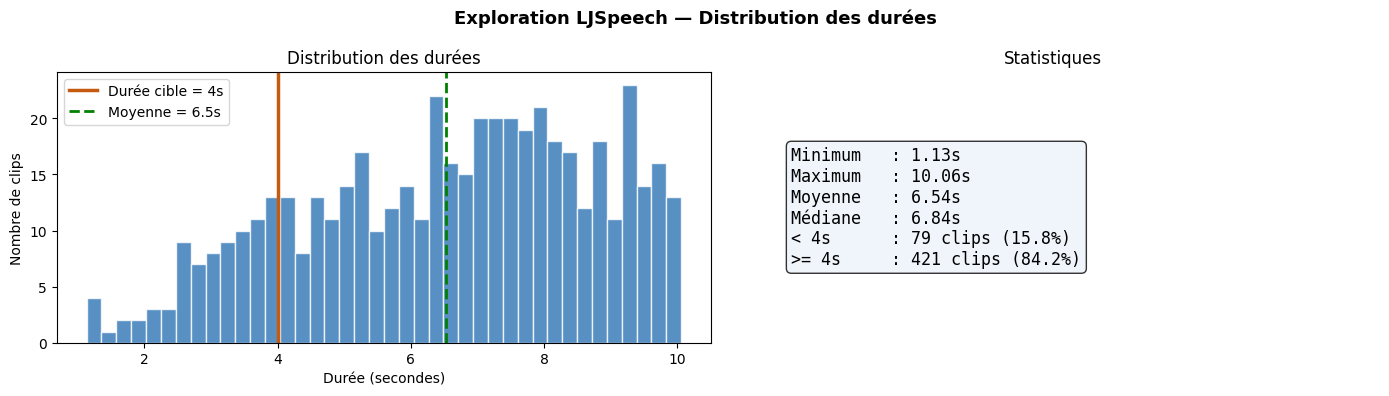


✅ Analyse terminée
   → Les clips < 4s seront paddés avec du silence
   → Les clips > 4s seront tronqués depuis le centre


In [44]:
# ── Analyse de la distribution des durées dans LJSpeech ──────────────────────
print('Analyse des durées LJSpeech (sur 500 fichiers)...')

durations = []
sample_files = random.sample(lj_files, min(500, len(lj_files)))

for f in tqdm(sample_files, desc='Lecture durées'):
    waveform, sr = torchaudio.load(str(f))
    duration = waveform.shape[1] / sr
    durations.append(duration)

durations = np.array(durations)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Exploration LJSpeech — Distribution des durées', fontsize=13, fontweight='bold')

# Histogramme des durées
axes[0].hist(durations, bins=40, color='#2E75B6', edgecolor='white', alpha=0.8)
axes[0].axvline(CLIP_DURATION, color='#C55A11', linewidth=2.5, 
                label=f'Durée cible = {CLIP_DURATION}s')
axes[0].axvline(np.mean(durations), color='green', linewidth=2, linestyle='--',
                label=f'Moyenne = {np.mean(durations):.1f}s')
axes[0].set_xlabel('Durée (secondes)')
axes[0].set_ylabel('Nombre de clips')
axes[0].set_title('Distribution des durées')
axes[0].legend()

# Statistiques
stats_text = (
    f'Minimum   : {durations.min():.2f}s\n'
    f'Maximum   : {durations.max():.2f}s\n'
    f'Moyenne   : {durations.mean():.2f}s\n'
    f'Médiane   : {np.median(durations):.2f}s\n'
    f'< 4s      : {(durations < 4).sum()} clips ({(durations < 4).mean()*100:.1f}%)\n'
    f'>= 4s     : {(durations >= 4).sum()} clips ({(durations >= 4).mean()*100:.1f}%)'
)
axes[1].text(0.1, 0.5, stats_text, transform=axes[1].transAxes,
             fontsize=12, verticalalignment='center',
             fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#EBF3FB', alpha=0.8))
axes[1].set_title('Statistiques')
axes[1].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'duration_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'\n✅ Analyse terminée')
print(f'   → Les clips < 4s seront paddés avec du silence')
print(f'   → Les clips > 4s seront tronqués depuis le centre')

---
## CELLULE 7 — Visualisation d'un spectrogramme LJSpeech

> Cette visualisation montre exactement ce que le CNN va "voir" comme image 2D.

📊 Matrice LFCC calculée :
   Forme               : torch.Size([20, 401])  (n_lfcc × frames_temporelles)
   Nombre de frames    : 401
   Durée couverte      : 4.01s
   Résolution temporelle: 10ms par frame
   Avant CMVN — min/max: -509.80 / 197.80
   Après CMVN — min/max: -4.16 / 3.77


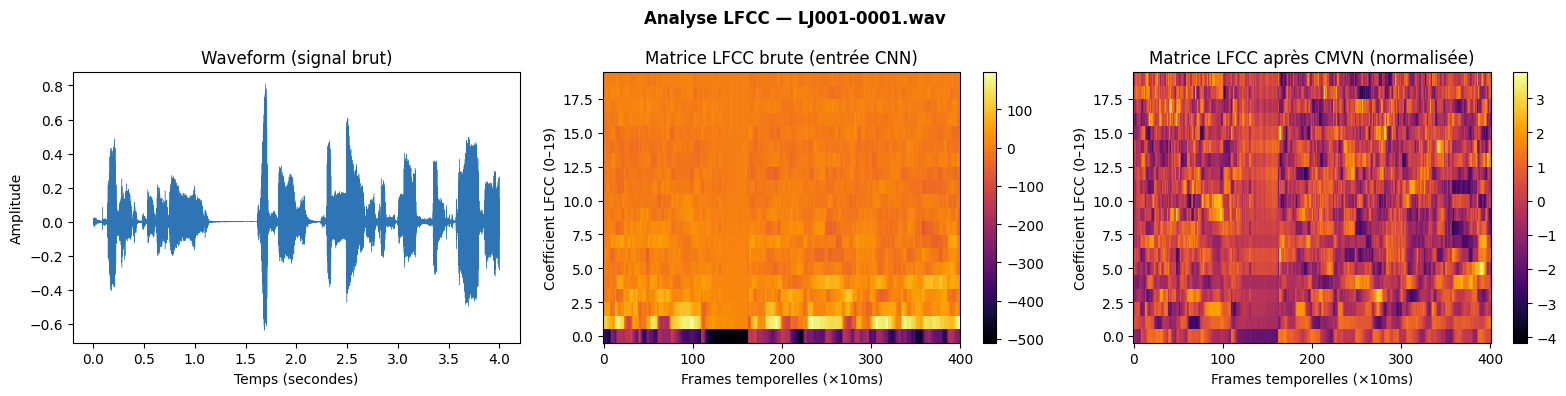


💡 Ce que tu vois :
   Axe horizontal = temps (chaque colonne = 10ms de signal)
   Axe vertical   = 20 coefficients LFCC (les lignes du bas = basses fréquences)
   Couleur        = énergie (jaune = fort, noir = faible)
   → C'est exactement cette image que le CNN va analyser pour détecter les anomalies


In [45]:
# ── Calculer et afficher la matrice LFCC d'un clip ───────────────────────────
# Utiliser un clip de longueur > 4s pour montrer la troncature
def get_duration(f):
    waveform, sr = torchaudio.load(str(f))
    return waveform.shape[1] / sr

long_files = [f for f in lj_files[:200] if get_duration(f) > 4]

demo_file = long_files[0] if long_files else lj_files[5]
waveform = load_audio(demo_file)  # (1, 64000)

# Extraction LFCC
# n_filter=128 filtres linéaires (≠ Mel), n_lfcc=20 coefficients finaux
lfcc_transform = T.LFCC(
    sample_rate=SAMPLE_RATE,
    n_filter=N_FILTER,
    n_lfcc=N_LFCC,
    speckwargs={'n_fft': N_FFT, 'hop_length': HOP_LENGTH, 'win_length': N_FFT}
)

lfcc = lfcc_transform(waveform)  # (1, 20, ~400)
lfcc = lfcc.squeeze(0)           # (20, ~400)

# CMVN : normalisation par moyenne et variance par utterance
# Pourquoi ? Élimine les effets de canal/micro — seuls les patterns restent
mean = lfcc.mean(dim=1, keepdim=True)
std  = lfcc.std(dim=1, keepdim=True) + 1e-8
lfcc_normalized = (lfcc - mean) / std

print(f'📊 Matrice LFCC calculée :')
print(f'   Forme               : {lfcc.shape}  (n_lfcc × frames_temporelles)')
print(f'   Nombre de frames    : {lfcc.shape[1]}')
print(f'   Durée couverte      : {lfcc.shape[1] * HOP_LENGTH / SAMPLE_RATE:.2f}s')
print(f'   Résolution temporelle: {HOP_LENGTH/SAMPLE_RATE*1000:.0f}ms par frame')
print(f'   Avant CMVN — min/max: {lfcc.min():.2f} / {lfcc.max():.2f}')
print(f'   Après CMVN — min/max: {lfcc_normalized.min():.2f} / {lfcc_normalized.max():.2f}')

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f'Analyse LFCC — {demo_file.name}', fontsize=12, fontweight='bold')

# Waveform
time_axis = np.linspace(0, CLIP_DURATION, CLIP_SAMPLES)
axes[0].plot(time_axis, waveform.squeeze().numpy(), color='#2E75B6', linewidth=0.3)
axes[0].set_xlabel('Temps (secondes)')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Waveform (signal brut)')

# LFCC avant normalisation
img1 = axes[1].imshow(lfcc.numpy(), aspect='auto', origin='lower',
                       cmap='inferno', interpolation='nearest')
axes[1].set_xlabel('Frames temporelles (×10ms)')
axes[1].set_ylabel('Coefficient LFCC (0–19)')
axes[1].set_title('Matrice LFCC brute (entrée CNN)')
plt.colorbar(img1, ax=axes[1])

# LFCC après CMVN
img2 = axes[2].imshow(lfcc_normalized.numpy(), aspect='auto', origin='lower',
                       cmap='inferno', interpolation='nearest')
axes[2].set_xlabel('Frames temporelles (×10ms)')
axes[2].set_ylabel('Coefficient LFCC (0–19)')
axes[2].set_title('Matrice LFCC après CMVN (normalisée)')
plt.colorbar(img2, ax=axes[2])

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'lfcc_visualization.png', dpi=100, bbox_inches='tight')
plt.show()

print('\n💡 Ce que tu vois :')
print('   Axe horizontal = temps (chaque colonne = 10ms de signal)')
print('   Axe vertical   = 20 coefficients LFCC (les lignes du bas = basses fréquences)')
print('   Couleur        = énergie (jaune = fort, noir = faible)')
print('   → C\'est exactement cette image que le CNN va analyser pour détecter les anomalies')

---
## CELLULE 8 — Rééchantillonnage LJSpeech (22050 Hz → 16000 Hz)

> LJSpeech est à 22050Hz. Tout le pipeline doit être à 16kHz.  
> On fait cette conversion UNE SEULE FOIS et on sauvegarde.

In [46]:
# ── Rééchantillonnage batch de tous les clips LJSpeech ───────────────────────
resampler_lj = T.Resample(orig_freq=22050, new_freq=SAMPLE_RATE)

# Vérification si déjà fait (pour ne pas refaire entre sessions)
already_done = list(RESAMPLED_LJ_DIR.glob('*.wav'))

if len(already_done) == len(lj_files):
    print(f'✅ Rééchantillonnage déjà fait — {len(already_done)} fichiers trouvés')
    print('   Passer à la cellule suivante')
else:
    print(f'🔄 Rééchantillonnage de {len(lj_files):,} fichiers LJSpeech...')
    print(f'   22050 Hz → {SAMPLE_RATE} Hz')
    
    errors = []
    for fpath in tqdm(lj_files, desc='Rééchantillonnage LJSpeech'):
        try:
            waveform, sr = torchaudio.load(str(fpath))
            
            # Rééchantillonnage
            if sr != SAMPLE_RATE:
                waveform = resampler_lj(waveform)
            
            # Mono si stéréo
            if waveform.shape[0] > 1:
                waveform = waveform.mean(dim=0, keepdim=True)
            
            # Sauvegarde (même nom de fichier, même dossier de sortie)
            out_path = RESAMPLED_LJ_DIR / fpath.name
            torchaudio.save(str(out_path), waveform, SAMPLE_RATE)
            
        except Exception as e:
            errors.append((fpath.name, str(e)))
    
    done_count = len(list(RESAMPLED_LJ_DIR.glob('*.wav')))
    print(f'\n✅ Rééchantillonnage terminé')
    print(f'   Fichiers traités  : {done_count:,}')
    print(f'   Erreurs           : {len(errors)}')
    if errors:
        print(f'   Premiers erreurs  : {errors[:3]}')

# Vérification du résultat
sample_resampled = list(RESAMPLED_LJ_DIR.glob('*.wav'))[0]
waveform_check, sr_check = torchaudio.load(str(sample_resampled))
print(f'\n📊 Vérification — {sample_resampled.name}:')
print(f'   Sample rate : {sr_check} Hz ✅' if sr_check == SAMPLE_RATE 
      else f'   ❌ Sample rate : {sr_check} Hz (attendu {SAMPLE_RATE})')

✅ Rééchantillonnage déjà fait — 13100 fichiers trouvés
   Passer à la cellule suivante

📊 Vérification — LJ002-0201.wav:
   Sample rate : 16000 Hz ✅


---
## CELLULE 9 — Simulateur de splices

> **C'est la partie la plus originale du projet.**  
> Ni ASVspoof ni WaveFake ne contiennent de splices forensiques (coupures Audacity-style).  
> On les simule à partir de LJSpeech — deux clips coupés et recollés avec crossfade.

```
Clip 1 : [=====|■■■■■■■■■■■■]
                ↑ cut1 (30-70%)
Clip 2 : [■■■■■■■■■■|=====]
                    ↑ cut2 (30-70%)

Résultat : [Clip1[:cut1] ~~crossfade~~ Clip2[cut2:]]
                         ↑ point de splice (labellisé)
```

In [47]:
def simulate_splice(clip1_path, clip2_path, 
                    crossfade_ms=CROSSFADE_MS, 
                    sample_rate=SAMPLE_RATE):
    """
    Génère un clip splicé en collant deux clips LJSpeech différents.
    
    Processus :
    1. Charger deux clips différents
    2. Couper clip1 à un point aléatoire entre 30% et 70% de sa durée
    3. Couper clip2 à un point aléatoire entre 30% et 70% de sa durée  
    4. Joindre [clip1[:cut1]] + [clip2[cut2:]]
    5. Appliquer un crossfade de 20ms à la jonction (comme un vrai forgeur)
    6. Retourner le clip splicé + la position du splice
    
    Args:
        clip1_path   : chemin vers le premier clip
        clip2_path   : chemin vers le deuxième clip
        crossfade_ms : durée du fondu enchaîné en ms (défaut: 20ms)
        sample_rate  : taux d'échantillonnage (défaut: 16000 Hz)
    
    Returns:
        spliced        : Tensor (1, N) — le clip splicé
        splice_sample  : int — position du splice en échantillons
        splice_frame   : int — position du splice en frames LFCC
    """
    wav1, sr1 = torchaudio.load(str(clip1_path))
    wav2, sr2 = torchaudio.load(str(clip2_path))
    
    # Rééchantillonnage si nécessaire
    if sr1 != sample_rate:
        wav1 = T.Resample(sr1, sample_rate)(wav1)
    if sr2 != sample_rate:
        wav2 = T.Resample(sr2, sample_rate)(wav2)
    
    # Mono
    if wav1.shape[0] > 1: wav1 = wav1.mean(0, keepdim=True)
    if wav2.shape[0] > 1: wav2 = wav2.mean(0, keepdim=True)
    
    # Points de coupure aléatoires (entre 30% et 70% pour éviter les bords silencieux)
    min_len = min(wav1.shape[1], wav2.shape[1])
    cut1 = random.randint(int(wav1.shape[1] * 0.3), int(wav1.shape[1] * 0.7))
    cut2 = random.randint(int(wav2.shape[1] * 0.3), int(wav2.shape[1] * 0.7))
    
    part1 = wav1[:, :cut1]       # début de clip1
    part2 = wav2[:, cut2:]       # fin de clip2
    
    # Crossfade à la jonction
    # Pourquoi ? Un vrai forgeur applique toujours un fondu pour masquer la coupure.
    # On simule ça pour que le modèle apprenne à détecter même les splices bien masqués.
    fade_samples = int(crossfade_ms * sample_rate / 1000)  # 20ms × 16000 = 320 samples
    fade_samples = min(fade_samples, part1.shape[1] - 1, part2.shape[1] - 1)
    
    if fade_samples > 0:
        # Fondu sortant sur la fin de part1
        fade_out = torch.linspace(1.0, 0.0, fade_samples)
        part1[:, -fade_samples:] *= fade_out
        
        # Fondu entrant sur le début de part2
        fade_in = torch.linspace(0.0, 1.0, fade_samples)
        part2[:, :fade_samples] *= fade_in
    
    # Assemblage
    spliced = torch.cat([part1, part2], dim=1)
    
    # Position du splice
    splice_sample = cut1
    splice_frame  = cut1 // HOP_LENGTH  # conversion samples → frame LFCC
    
    return spliced, splice_sample, splice_frame


print('✅ simulate_splice() définie')
print(f'   Crossfade : {CROSSFADE_MS}ms = {int(CROSSFADE_MS * SAMPLE_RATE / 1000)} échantillons')
print(f'   Points de coupure : entre 30% et 70% de chaque clip')

✅ simulate_splice() définie
   Crossfade : 20ms = 320 échantillons
   Points de coupure : entre 30% et 70% de chaque clip


---
## CELLULE 10 — Test du simulateur de splices + visualisation

📊 Test simulate_splice():
   Clip 1 source     : LJ010-0310.wav
   Clip 2 source     : LJ025-0018.wav
   Résultat shape    : torch.Size([1, 89421])
   Position splice   : échantillon 43,621 = 2.73s
   Frame LFCC splice : 272 (sur ~400 frames totales)


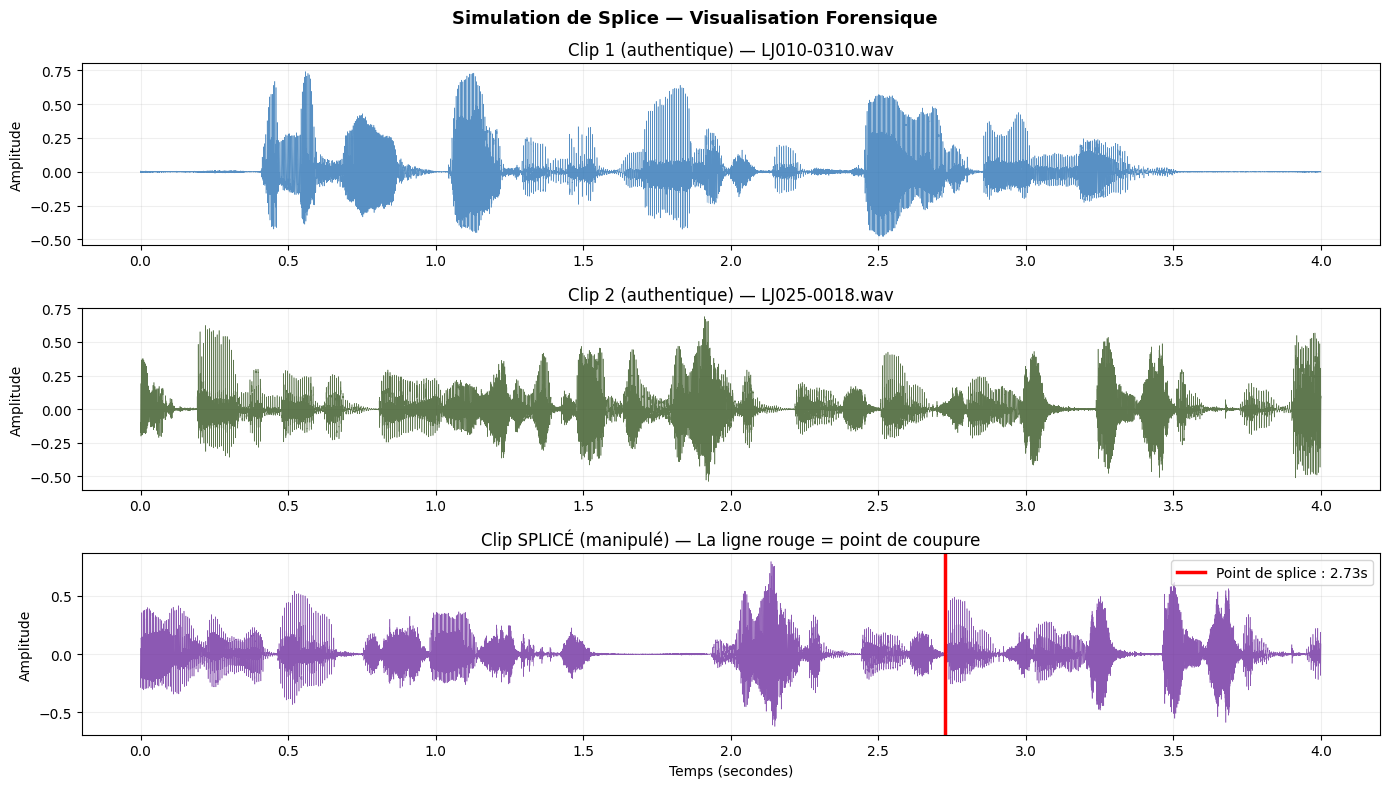


💡 Observation clé :
   À l'oreille, ce splice peut sembler naturel
   Sur le spectrogramme, une discontinuité de phase sera visible au point rouge
   C'est exactement ce que le CNN-LSTM doit apprendre à détecter


In [48]:
# ── Test visuel du simulateur ─────────────────────────────────────────────────
resampled_files = sorted(RESAMPLED_LJ_DIR.glob('*.wav'))

clip1_path, clip2_path = random.sample(resampled_files, 2)
spliced, splice_sample, splice_frame = simulate_splice(clip1_path, clip2_path)

print(f'📊 Test simulate_splice():')
print(f'   Clip 1 source     : {clip1_path.name}')
print(f'   Clip 2 source     : {clip2_path.name}')
print(f'   Résultat shape    : {spliced.shape}')
print(f'   Position splice   : échantillon {splice_sample:,} = {splice_sample/SAMPLE_RATE:.2f}s')
print(f'   Frame LFCC splice : {splice_frame} (sur ~{CLIP_SAMPLES//HOP_LENGTH} frames totales)')

# Appliquer normalize_length pour avoir exactement 4s
spliced_normalized = normalize_length(normalize_amplitude(spliced))

# Charger les clips originaux pour comparaison
original1 = load_audio(clip1_path)
original2 = load_audio(clip2_path)

# Visualisation
fig, axes = plt.subplots(3, 1, figsize=(14, 8))
fig.suptitle('Simulation de Splice — Visualisation Forensique', 
             fontsize=13, fontweight='bold')

time_axis = np.linspace(0, CLIP_DURATION, CLIP_SAMPLES)

# Clip 1 original
axes[0].plot(time_axis, original1.squeeze().numpy(), 
             color='#2E75B6', linewidth=0.4, alpha=0.8)
axes[0].set_title(f'Clip 1 (authentique) — {clip1_path.name}')
axes[0].set_ylabel('Amplitude')

# Clip 2 original  
axes[1].plot(time_axis, original2.squeeze().numpy(), 
             color='#375623', linewidth=0.4, alpha=0.8)
axes[1].set_title(f'Clip 2 (authentique) — {clip2_path.name}')
axes[1].set_ylabel('Amplitude')

# Clip splicé
splice_time = splice_sample / SAMPLE_RATE
axes[2].plot(time_axis, spliced_normalized.squeeze().numpy(), 
             color='#7030A0', linewidth=0.4, alpha=0.8)

# Ligne rouge = point de splice (si dans les 4 premières secondes)
if splice_time <= CLIP_DURATION:
    axes[2].axvline(x=splice_time, color='red', linewidth=2.5, 
                    label=f'Point de splice : {splice_time:.2f}s')
    axes[2].legend(loc='upper right')

axes[2].set_title('Clip SPLICÉ (manipulé) — La ligne rouge = point de coupure')
axes[2].set_xlabel('Temps (secondes)')
axes[2].set_ylabel('Amplitude')

for ax in axes:
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'splice_example.png', dpi=100, bbox_inches='tight')
plt.show()

print('\n💡 Observation clé :')
print('   À l\'oreille, ce splice peut sembler naturel')
print('   Sur le spectrogramme, une discontinuité de phase sera visible au point rouge')
print('   C\'est exactement ce que le CNN-LSTM doit apprendre à détecter')

---
## CELLULE 11 — Génération des 1000 clips splicés

In [49]:
# ── Génération batch de 1000 splices ─────────────────────────────────────────
# Vérification si déjà fait
existing_splices = list(SPLICED_DIR.glob('splice_*.wav'))

if len(existing_splices) >= N_SPLICES:
    print(f'✅ {len(existing_splices)} splices déjà générés — chargement des métadonnées')
    splice_records = pd.read_csv(SPLICED_DIR / 'splice_labels.csv').to_dict('records')
else:
    print(f'🔄 Génération de {N_SPLICES} clips splicés...')
    splice_records = []
    errors_splice = []
    
    for i in tqdm(range(N_SPLICES), desc='Génération splices'):
        try:
            # Choisir 2 clips DIFFÉRENTS aléatoirement
            clip1_p, clip2_p = random.sample(resampled_files, 2)
            
            # Simuler le splice
            spliced, splice_sample, splice_frame = simulate_splice(clip1_p, clip2_p)
            
            # Normaliser longueur et amplitude
            spliced = normalize_length(normalize_amplitude(spliced))
            
            # Sauvegarder le clip
            out_name = f'splice_{i:05d}.wav'
            out_path = SPLICED_DIR / out_name
            torchaudio.save(str(out_path), spliced, SAMPLE_RATE)
            
            # Enregistrer les métadonnées
            splice_records.append({
                'filename'      : out_name,
                'filepath'      : str(out_path),
                'source_clip1'  : clip1_p.name,
                'source_clip2'  : clip2_p.name,
                'splice_sample' : splice_sample,
                'splice_frame'  : splice_frame,
                'splice_time_s' : round(splice_sample / SAMPLE_RATE, 4),
                'label'         : 1,            # 1 = manipulé
                'tamper_type'   : 'splice',
                'source_dataset': 'ljspeech_simulated'
            })
            
        except Exception as e:
            errors_splice.append(i)
    
    # Sauvegarder les métadonnées
    splice_df = pd.DataFrame(splice_records)
    splice_df.to_csv(SPLICED_DIR / 'splice_labels.csv', index=False)
    
    print(f'\n✅ Génération terminée')
    print(f'   Clips générés : {len(splice_records)}')
    print(f'   Erreurs       : {len(errors_splice)}')
    print(f'   Labels sauvés : {SPLICED_DIR}/splice_labels.csv')
    
    if len(splice_records) > 0:
        print(f'\n   Exemple de métadonnées :')
        print(pd.DataFrame(splice_records).head(3).to_string())

✅ 1000 splices déjà générés — chargement des métadonnées


---
## CELLULE 12 — Parsing des labels ASVspoof2019 LA

> Le fichier de labels ASVspoof a un format spécifique — on le parse ici.

In [50]:
def parse_asvspooof_protocol(protocol_file, flac_dir):
    """
    Parse un fichier de protocole ASVspoof2019 LA.
    
    Format d'une ligne :
    LA_0001  LA_T_000001  -  AA  bonafide
    speaker  filename     -  sys label
    
    Args:
        protocol_file : chemin vers le .txt de labels
        flac_dir      : chemin vers le dossier contenant les .flac
    
    Returns:
        DataFrame avec colonnes : filename, filepath, label, system_id,
                                  tamper_type, source_dataset, split
    """
    records = []
    
    with open(protocol_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            
            speaker_id = parts[0]   # ex: LA_0001
            filename   = parts[1]   # ex: LA_T_000001
            system_id  = parts[3]   # ex: A01 ou '-' pour bonafide
            label_str  = parts[4]   # 'bonafide' ou 'spoof'
            
            flac_path = Path(flac_dir) / f'{filename}.flac'
            
            # Vérifier que le fichier existe
            if not flac_path.exists():
                continue
            
            # Déterminer le type de manipulation
            if label_str == 'bonafide':
                label      = 0
                tamper_type = 'authentic'
            else:
                label      = 1
                tamper_type = f'deepfake_tts_{system_id}'  # ex: deepfake_tts_A01
            
            records.append({
                'filename'      : filename,
                'filepath'      : str(flac_path),
                'label'         : label,
                'system_id'     : system_id,
                'tamper_type'   : tamper_type,
                'source_dataset': 'asvspoof2019_la'
            })
    
    return pd.DataFrame(records)


# ── Parser les 3 partitions (train, dev, eval) ────────────────────────────────
protocols_dir = ASVSPOOOF_DIR / 'ASVspoof2019_LA_cm_protocols'

# Trouver les fichiers de protocoles
protocol_files = {
    'train': protocols_dir / 'ASVspoof2019.LA.cm.train.trn.txt',
    'dev'  : protocols_dir / 'ASVspoof2019.LA.cm.dev.trl.txt',
    'eval' : protocols_dir / 'ASVspoof2019.LA.cm.eval.trl.txt',
}

flac_dirs = {
    'train': ASVSPOOOF_DIR / 'ASVspoof2019_LA_train' / 'flac',
    'dev'  : ASVSPOOOF_DIR / 'ASVspoof2019_LA_dev'   / 'flac',
    'eval' : ASVSPOOOF_DIR / 'ASVspoof2019_LA_eval'  / 'flac',
}

asv_dfs = {}
for split_name, proto_path in protocol_files.items():
    if proto_path.exists():
        df = parse_asvspooof_protocol(proto_path, flac_dirs[split_name])
        df['split'] = split_name
        asv_dfs[split_name] = df
        print(f'✅ ASVspoof {split_name:5s}: {len(df):6,} clips '
              f'| bonafide: {(df.label==0).sum():5,} '
              f'| spoof: {(df.label==1).sum():6,}')
    else:
        print(f'⚠️  Fichier non trouvé : {proto_path}')
        print(f'   Vérifier le chemin ASVSPOOOF_DIR = {ASVSPOOOF_DIR}')

if asv_dfs:
    asv_all = pd.concat(asv_dfs.values(), ignore_index=True)
    print(f'\n📊 ASVspoof total : {len(asv_all):,} clips')
    print(f'   Ratio bonafide:spoof = 1:{(asv_all.label==1).sum()/(asv_all.label==0).sum():.1f}')

✅ ASVspoof train: 25,380 clips | bonafide: 2,580 | spoof: 22,800
✅ ASVspoof dev  : 24,844 clips | bonafide: 2,548 | spoof: 22,296
✅ ASVspoof eval : 71,237 clips | bonafide: 7,355 | spoof: 63,882

📊 ASVspoof total : 121,461 clips
   Ratio bonafide:spoof = 1:8.7


---
## CELLULE 13 — Intégration WaveFake

In [51]:
# ── Scanner les dossiers WaveFake ─────────────────────────────────────────────
print('🔍 Scan des dossiers WaveFake...')

wavefake_records = []
vocoder_stats    = {}

if WAVEFAKE_DIR.exists():
    # WaveFake est organisé par vocoder : generated_audio/ljspeech_hifiganV1/*.wav
    for vocoder_dir in sorted(WAVEFAKE_DIR.iterdir()):
        if not vocoder_dir.is_dir():
            continue
        
        wav_files = list(vocoder_dir.glob('*.wav'))
        vocoder_stats[vocoder_dir.name] = len(wav_files)
        
        for wav_path in wav_files:
            wavefake_records.append({
                'filename'      : wav_path.name,
                'filepath'      : str(wav_path),
                'label'         : 1,  # tous les clips WaveFake sont faux
                'system_id'     : vocoder_dir.name,
                'tamper_type'   : f'deepfake_vocoder_{vocoder_dir.name}',
                'source_dataset': 'wavefake'
            })
    
    # LJSpeech original dans WaveFake (les fichiers authentiques)
    # Chercher les fichiers LJSpeech correspondants
    lj_authentic_wavefake = list(RESAMPLED_LJ_DIR.glob('*.wav'))[:13000]
    
    print('\n📊 Statistiques WaveFake par vocoder :')
    for vocoder, count in sorted(vocoder_stats.items()):
        print(f'   {vocoder:35s} : {count:6,} clips')
    print(f'\n   Total faux  : {len(wavefake_records):,}')
    print(f'   Authentiques: {len(lj_authentic_wavefake):,} (LJSpeech rééchantillonné)')

else:
    print(f'⚠️  WaveFake non trouvé à : {WAVEFAKE_DIR}')
    print('   Continuer sans WaveFake — seulement ASVspoof + LJSpeech')
    wavefake_records = []

🔍 Scan des dossiers WaveFake...

📊 Statistiques WaveFake par vocoder :
   jsut_multi_band_melgan              :  5,000 clips
   jsut_parallel_wavegan               :     72 clips
   ljspeech_full_band_melgan           : 13,100 clips
   ljspeech_melgan                     :  7,975 clips
   ljspeech_melgan_large               : 13,100 clips
   ljspeech_multi_band_melgan          : 13,100 clips
   ljspeech_parallel_wavegan           :  1,414 clips
   ljspeech_waveglow                   : 13,100 clips

   Total faux  : 66,861
   Authentiques: 13,000 (LJSpeech rééchantillonné)


---
## CELLULE 14 — Construction du master_labels.csv unifié

> Un seul fichier CSV pour gouverner tous les datasets.

In [52]:
# ── Assembler toutes les sources en un seul DataFrame ─────────────────────────
print('🔄 Construction du master_labels.csv...')

all_records = []

# ── Source 1 : LJSpeech authentique ──
# On prend 3000 clips authentiques pour équilibrer avec nos 1000 splices + faux ASVspoof
lj_authentic_files = random.sample(list(RESAMPLED_LJ_DIR.glob('*.wav')), 
                                    min(3000, len(list(RESAMPLED_LJ_DIR.glob('*.wav')))))
for fp in lj_authentic_files:
    all_records.append({
        'filename'      : fp.name,
        'filepath'      : str(fp),
        'label'         : 0,
        'system_id'     : '-',
        'tamper_type'   : 'authentic',
        'source_dataset': 'ljspeech'
    })
print(f'   LJSpeech authentique  : {len(lj_authentic_files):,} clips')

# ── Source 2 : Splices simulés ──
if splice_records:
    all_records.extend(splice_records)
    print(f'   Splices simulés       : {len(splice_records):,} clips')

# ── Source 3 : ASVspoof2019 LA ──
if asv_dfs:
    for _, row in asv_all.iterrows():
        all_records.append(row.to_dict())
    print(f'   ASVspoof2019 LA       : {len(asv_all):,} clips')

# ── Source 4 : WaveFake (optionnel — peut être très lourd) ──
# On prend un sous-ensemble si WaveFake est présent
if wavefake_records:
    # Équilibrage : max 5000 clips par vocoder
    wf_df = pd.DataFrame(wavefake_records)
    wf_sampled = wf_df.groupby('system_id').apply(
        lambda x: x.sample(min(len(x), 2000), random_state=SEED)
    ).reset_index(drop=True)
    for _, row in wf_sampled.iterrows():
        all_records.append(row.to_dict())
    print(f'   WaveFake (sous-éch.)  : {len(wf_sampled):,} clips')

# ── Créer le DataFrame maître ──
master_df = pd.DataFrame(all_records)

# S'assurer que les colonnes essentielles existent
for col in ['filename', 'filepath', 'label', 'tamper_type', 'source_dataset']:
    if col not in master_df.columns:
        master_df[col] = 'unknown'

# Mélanger aléatoirement AVANT le split (crucial pour éviter les biais temporels)
master_df = master_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

# ── Split 80/10/10 ──
# IMPORTANT : pour ASVspoof, on GARDE les splits officiels
# Pour LJSpeech et splices, on fait le split ici
n = len(master_df)
train_end = int(n * 0.80)
val_end   = int(n * 0.90)

# Initialiser tous comme 'train'
master_df['split'] = 'train'

# Remplacer les splits officiels ASVspoof
if 'split' in master_df.columns:
    asv_mask = master_df['source_dataset'] == 'asvspoof2019_la'
    # Les splits ASVspoof sont déjà dans la colonne 'split'

# Pour les autres sources, appliquer 80/10/10
non_asv_mask = master_df['source_dataset'] != 'asvspoof2019_la'
non_asv_indices = master_df[non_asv_mask].index.tolist()
n_non_asv = len(non_asv_indices)

train_end_na = int(n_non_asv * 0.80)
val_end_na   = int(n_non_asv * 0.90)

master_df.loc[non_asv_indices[train_end_na:val_end_na], 'split'] = 'val'
master_df.loc[non_asv_indices[val_end_na:],             'split'] = 'test'

# Sauvegarder
master_csv_path = SPLITS_DIR / 'master_labels.csv'
master_df.to_csv(master_csv_path, index=False)

print(f'\n✅ master_labels.csv créé : {master_csv_path}')
print(f'   Total clips : {len(master_df):,}')

🔄 Construction du master_labels.csv...
   LJSpeech authentique  : 3,000 clips
   Splices simulés       : 1,000 clips
   ASVspoof2019 LA       : 121,461 clips
   WaveFake (sous-éch.)  : 13,486 clips

✅ master_labels.csv créé : /kaggle/working/splits/master_labels.csv
   Total clips : 138,947


---
## CELLULE 15 — Analyse du dataset final + visualisations

RÉSUMÉ DU DATASET FINAL

📊 Distribution des labels :
   Authentique (0) : 15,483 (11.1%)
   Manipulé    (1) : 123,464 (88.9%)
   Ratio           : 1:8.0

📊 Distribution par type de manipulation :
tamper_type
authentic                                      15483
deepfake_tts_A02                                7516
deepfake_tts_A05                                7516
deepfake_tts_A06                                7516
deepfake_tts_A04                                7516
deepfake_tts_A03                                7516
deepfake_tts_A01                                7516
deepfake_tts_A18                                4914
deepfake_tts_A10                                4914
deepfake_tts_A11                                4914
deepfake_tts_A19                                4914
deepfake_tts_A09                                4914
deepfake_tts_A13                                4914
deepfake_tts_A14                                4914
deepfake_tts_A17                                49

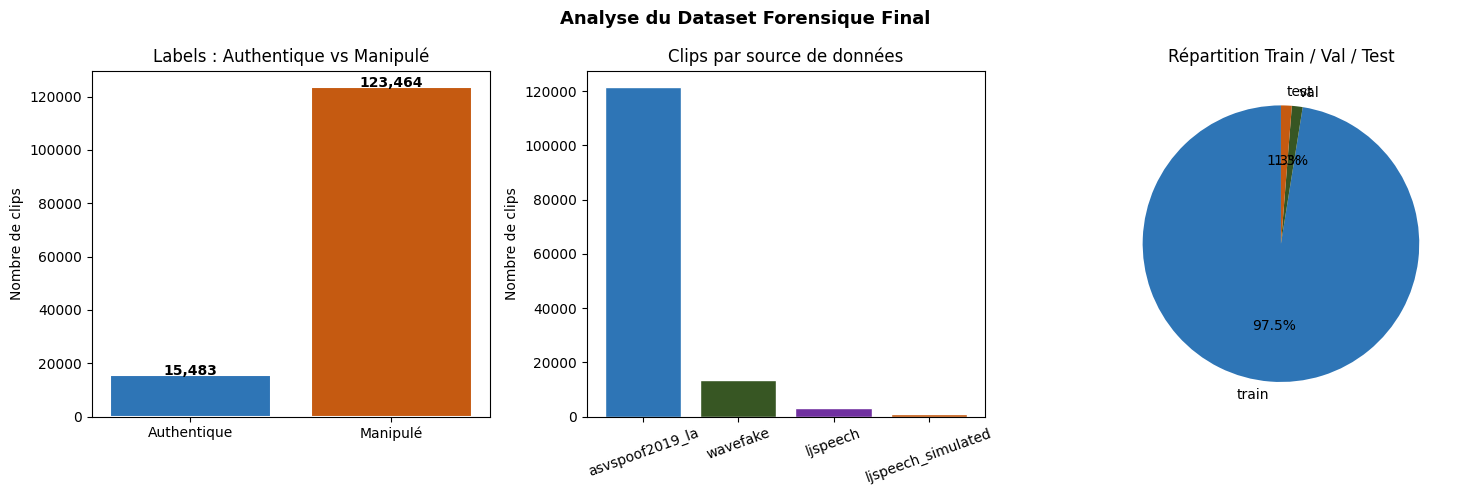


⚠️  Note sur le déséquilibre de classes :
   Ratio 1:8.0 — utiliser WeightedRandomSampler dans le DataLoader
   Voir Notebook 3 (Training) pour la gestion du déséquilibre


In [53]:
# ── Statistiques complètes du dataset final ───────────────────────────────────
print('=' * 60)
print('RÉSUMÉ DU DATASET FINAL')
print('=' * 60)

print('\n📊 Distribution des labels :')
label_counts = master_df['label'].value_counts()
total = len(master_df)
print(f'   Authentique (0) : {label_counts.get(0, 0):,} ({label_counts.get(0, 0)/total*100:.1f}%)')
print(f'   Manipulé    (1) : {label_counts.get(1, 0):,} ({label_counts.get(1, 0)/total*100:.1f}%)')
print(f'   Ratio           : 1:{label_counts.get(1,0)/max(label_counts.get(0,1),1):.1f}')

print('\n📊 Distribution par type de manipulation :')
print(master_df['tamper_type'].value_counts().to_string())

print('\n📊 Distribution par source :')
print(master_df['source_dataset'].value_counts().to_string())

print('\n📊 Distribution par split :')
print(master_df['split'].value_counts().to_string())

# Visualisations
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Analyse du Dataset Forensique Final', fontsize=13, fontweight='bold')

colors_label = ['#2E75B6', '#C55A11']
label_names  = ['Authentique', 'Manipulé']

# Distribution labels
counts = [label_counts.get(0, 0), label_counts.get(1, 0)]
axes[0].bar(label_names, counts, color=colors_label, edgecolor='white', linewidth=1.5)
axes[0].set_title('Labels : Authentique vs Manipulé')
axes[0].set_ylabel('Nombre de clips')
for i, v in enumerate(counts):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# Distribution sources
src_counts = master_df['source_dataset'].value_counts()
axes[1].bar(src_counts.index, src_counts.values, 
            color=['#2E75B6', '#375623', '#7030A0', '#C55A11'][:len(src_counts)],
            edgecolor='white')
axes[1].set_title('Clips par source de données')
axes[1].set_ylabel('Nombre de clips')
axes[1].tick_params(axis='x', rotation=20)

# Distribution splits
split_counts = master_df['split'].value_counts()
axes[2].pie(split_counts.values, labels=split_counts.index,
            autopct='%1.1f%%', colors=['#2E75B6', '#375623', '#C55A11'],
            startangle=90)
axes[2].set_title('Répartition Train / Val / Test')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'dataset_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print('\n⚠️  Note sur le déséquilibre de classes :')
ratio = label_counts.get(1, 0) / max(label_counts.get(0, 1), 1)
if ratio > 2:
    print(f'   Ratio 1:{ratio:.1f} — utiliser WeightedRandomSampler dans le DataLoader')
    print('   Voir Notebook 3 (Training) pour la gestion du déséquilibre')
else:
    print(f'   Ratio 1:{ratio:.1f} — dataset relativement équilibré ✅')

---
## CELLULE 16 — Vérification finale + récapitulatif des outputs

In [54]:
# ── Vérifications finales ─────────────────────────────────────────────────────
print('=' * 60)
print('VÉRIFICATIONS FINALES')
print('=' * 60)

checks_passed = 0
checks_total  = 0

def check(condition, message):
    global checks_passed, checks_total
    checks_total += 1
    status = '✅' if condition else '❌'
    print(f'   {status} {message}')
    if condition:
        checks_passed += 1

# Test 1 : master_labels.csv existe
check(master_csv_path.exists(), 
      f'master_labels.csv existe ({len(master_df):,} lignes)')

# Test 2 : toutes les colonnes essentielles présentes
required_cols = ['filename', 'filepath', 'label', 'tamper_type', 'source_dataset', 'split']
check(all(c in master_df.columns for c in required_cols),
      f'Colonnes essentielles présentes : {required_cols}')

# Test 3 : labels valides (0 ou 1 seulement)
check(master_df['label'].isin([0, 1]).all(),
      'Labels valides (0 = authentique, 1 = manipulé)')

# Test 4 : pas de chemins manquants (sur 100 samples)
sample_paths = master_df['filepath'].sample(100, random_state=SEED)
missing = sum(1 for p in sample_paths if not Path(p).exists())
check(missing == 0, f'Fichiers accessibles (0 manquants sur 100 testés)')

# Test 5 : clips splicés générés
n_splices_done = len(list(SPLICED_DIR.glob('splice_*.wav')))
check(n_splices_done >= N_SPLICES * 0.95,
      f'Splices générés : {n_splices_done}/{N_SPLICES}')

# Test 6 : LJSpeech rééchantillonné
n_resampled = len(list(RESAMPLED_LJ_DIR.glob('*.wav')))
check(n_resampled > 10000,
      f'LJSpeech rééchantillonné : {n_resampled:,} fichiers')

# Test 7 : vérifier shape d'un clip traité
test_clip = load_audio(master_df['filepath'].iloc[0])
check(test_clip.shape == (1, CLIP_SAMPLES),
      f'Shape clip : {test_clip.shape} == (1, {CLIP_SAMPLES})')

print(f'\n{'='*60}')
print(f'RÉSULTAT : {checks_passed}/{checks_total} vérifications passées')

if checks_passed == checks_total:
    print('\n🎉 NOTEBOOK 1 TERMINÉ AVEC SUCCÈS')
    print('\n📂 Outputs sauvegardés dans /kaggle/working/ :')
    print(f'   ✅ ljspeech_16k/           — {n_resampled:,} clips à 16kHz')
    print(f'   ✅ spliced/                — {n_splices_done} splices simulés')
    print(f'   ✅ splits/master_labels.csv — {len(master_df):,} clips labellisés')
    print(f'   ✅ duration_distribution.png')
    print(f'   ✅ lfcc_visualization.png')
    print(f'   ✅ splice_example.png')
    print(f'   ✅ dataset_analysis.png')
    print()
    print('⏭️  PROCHAIN NOTEBOOK : 02_feature_extraction.ipynb')
    print('   → Extraction LFCC sur tous les clips → sauvegarde .npy')
    print('   → Input : master_labels.csv + fichiers audio')
    print('   → Output : lfcc_features/ (matrice (20, 400) par clip)')
else:
    print('\n⚠️  Certaines vérifications ont échoué — corriger avant de continuer')

VÉRIFICATIONS FINALES
   ✅ master_labels.csv existe (138,947 lignes)
   ✅ Colonnes essentielles présentes : ['filename', 'filepath', 'label', 'tamper_type', 'source_dataset', 'split']
   ✅ Labels valides (0 = authentique, 1 = manipulé)
   ✅ Fichiers accessibles (0 manquants sur 100 testés)
   ✅ Splices générés : 1000/1000
   ✅ LJSpeech rééchantillonné : 13,100 fichiers
   ✅ Shape clip : torch.Size([1, 64000]) == (1, 64000)

RÉSULTAT : 7/7 vérifications passées

🎉 NOTEBOOK 1 TERMINÉ AVEC SUCCÈS

📂 Outputs sauvegardés dans /kaggle/working/ :
   ✅ ljspeech_16k/           — 13,100 clips à 16kHz
   ✅ spliced/                — 1000 splices simulés
   ✅ splits/master_labels.csv — 138,947 clips labellisés
   ✅ duration_distribution.png
   ✅ lfcc_visualization.png
   ✅ splice_example.png
   ✅ dataset_analysis.png

⏭️  PROCHAIN NOTEBOOK : 02_feature_extraction.ipynb
   → Extraction LFCC sur tous les clips → sauvegarde .npy
   → Input : master_labels.csv + fichiers audio
   → Output : lfcc_featur

---
## ⏭️ Transition vers le Notebook 2

### Ce que le Notebook 2 va recevoir de toi :
```
/kaggle/working/splits/master_labels.csv   ← ta bible pour tout le projet
/kaggle/working/ljspeech_16k/*.wav         ← clips authentiques à 16kHz
/kaggle/working/spliced/splice_*.wav       ← clips splicés simulés
/kaggle/input/asvspoof2019/LA/.../flac/    ← clips ASVspoof
/kaggle/input/wavefake/generated_audio/    ← clips WaveFake
```

### Ce que le Notebook 2 va produire :
```
/kaggle/working/lfcc_features/*.npy        ← matrice (20, 400) par clip
```

### ⚠️ Avant de fermer cette session
1. Aller dans **Output** (panneau droit Kaggle)
2. Cliquer **"Add to Dataset"** sur le dossier `/kaggle/working/`
3. Nommer le dataset : `forensic-audio-preprocessing`
4. Ce dataset sera disponible dans le Notebook 2 sous `/kaggle/input/forensic-audio-preprocessing/`

In [56]:
import subprocess
import os

print("📦 Création du dataset depuis /kaggle/working/...")

# Vérifie ce qui existe
dirs_to_check = ['ljspeech_16k', 'spliced', 'splits']
for d in dirs_to_check:
    path = Path('/kaggle/working/') / d
    if path.exists():
        count = len(list(path.glob('*')))
        print(f'  ✅ {d}/ → {count} fichiers')
    else:
        print(f'  ❌ {d}/ → MANQUANT')

# Affiche la taille totale
result = subprocess.run(['du', '-sh', '/kaggle/working/'], 
                       capture_output=True, text=True)
print(f'\n📊 Taille totale : {result.stdout.strip()}')

print('\n✅ Notebook 1 terminé — prêt pour le commit')
print('   → Clique Save & Run All (Commit)')
print('   → Ensuite va dans Output et clique "New Dataset"')
print('   → Nomme-le : forensic-audio-preprocessing')

📦 Création du dataset depuis /kaggle/working/...
  ✅ ljspeech_16k/ → 13100 fichiers
  ✅ spliced/ → 1001 fichiers
  ✅ splits/ → 1 fichiers

📊 Taille totale : 2.8G	/kaggle/working/

✅ Notebook 1 terminé — prêt pour le commit
   → Clique Save & Run All (Commit)
   → Ensuite va dans Output et clique "New Dataset"
   → Nomme-le : forensic-audio-preprocessing


In [57]:
import subprocess
import json

metadata = {
    "title": "forensic-audio-preprocessing",
    "id": "elmiz20042004/forensic-audio-preprocessing",
    "licenses": [{"name": "CC0-1.0"}]
}

with open('/kaggle/working/dataset-metadata.json', 'w') as f:
    json.dump(metadata, f)

print('📤 Upload vers Kaggle...')
result = subprocess.run(
    ['kaggle', 'datasets', 'create', '-p', '/kaggle/working/', '--dir-mode', 'zip'],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print(f'❌ Erreur : {result.stderr}')
else:
    print('✅ Dataset créé ! Disponible sur kaggle.com/datasets/elmiz20042004/forensic-audio-preprocessing')

📤 Upload vers Kaggle...
Starting upload for file ljspeech_16k.zip
Upload successful: ljspeech_16k.zip (2GB)
Starting upload for file dataset_analysis.png
Upload successful: dataset_analysis.png (63KB)
Starting upload for file splits.zip
Upload successful: splits.zip (2MB)
Starting upload for file duration_distribution.png
Upload successful: duration_distribution.png (46KB)
Starting upload for file spliced.zip
Upload successful: spliced.zip (105MB)
Starting upload for file .virtual_documents.zip
Upload successful: .virtual_documents.zip (12KB)
Starting upload for file lfcc_visualization.png
Upload successful: lfcc_visualization.png (103KB)
Starting upload for file splice_example.png
Upload successful: splice_example.png (184KB)
Your private Dataset is being created. Please check progress at https://www.kaggle.com/datasets/elmiz20042004/forensic-audio-preprocessing

✅ Dataset créé ! Disponible sur kaggle.com/datasets/elmiz20042004/forensic-audio-preprocessing
